In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

# Loading the CSV file
csv_path = "Files/FInal result for project.csv"
df = spark.read.option("header", True).option("inferSchema", True).csv(csv_path)

display(df.limit(5))
print(" CSV loaded successfully!")


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 4, Finished, Available, Finished)

SynapseWidget(Synapse.DataFrame, b759c2bc-d11f-4794-81eb-9c5b52602da4)

 CSV loaded successfully!


In [3]:
parquet_path = "Files/fitbit_parquet"
df.write.mode("overwrite").parquet(parquet_path)

print(" Parquet folder created successfully at:", parquet_path)


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 5, Finished, Available, Finished)

 Parquet folder created successfully at: Files/fitbit_parquet


In [4]:
# Read Parquet
df_parquet = spark.read.parquet(parquet_path)

# Save as Delta
delta_path = "Tables/fitbit_delta_table"
df_parquet.write.format("delta").mode("overwrite").save(delta_path)

print("Parquet converted to Delta table at:", delta_path)


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 6, Finished, Available, Finished)

Parquet converted to Delta table at: Tables/fitbit_delta_table


In [5]:
display(
    delta_table.toDF()
    .select("Id")
    .distinct()
    .limit(5)
)


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 7, Finished, Available, Finished)

NameError: name 'delta_table' is not defined

In [ ]:
display(delta_table.toDF().limit(10))
print("Final rows before deletion:", delta_table.toDF().count())

StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [ ]:
# Filter and show the exact record before deleting
record_to_delete = delta_table.toDF().filter(
    "Id = 8792009665 AND Steps_HourlySum = 45 AND Hour = 1"
)

display(record_to_delete)
print("Matching records before delete:", record_to_delete.count())


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [ ]:
from delta.tables import DeltaTable

# Load Delta table
delta_table = DeltaTable.forPath(spark, delta_path)

print("Before delete:", delta_table.toDF().count())

# Delete one record (replace ID value with one from your dataset)
delta_table.delete("Id = 8792009665 AND Steps_HourlySum = 45 AND Hour = 1")

print("After delete:", delta_table.toDF().count())
print(" One record deleted successfully.")


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [ ]:
# Filter and show the exact record before deleting
record_to_delete = delta_table.toDF().filter(
    "Id = 8792009665 AND Steps_HourlySum = 45 AND Hour = 1"
)

display(record_to_delete)
print("Matching records after delete:", record_to_delete.count())

StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [ ]:
history_df = delta_table.history()
display(history_df)


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [ ]:
display(delta_table.toDF().limit(10))
print("Final rows after deletion:", delta_table.toDF().count())


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

In [6]:
#Added for Deliverable 3 
source_tbl = "fitbit_delta_table"   
use_parquet_instead = False         

from pyspark.sql import functions as F

if use_parquet_instead:
    df0 = spark.read.parquet("/lakehouse/default/Files/fitbit_parquet")
else:
    df0 = spark.table(source_tbl)

df0.printSchema()
df0.limit(5).toPandas()  # quick peek


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 8, Finished, Available, Finished)

root
 |-- Id: long (nullable = true)
 |-- Date: date (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Steps_HourlySum: integer (nullable = true)
 |-- Steps_HourlyAvg: double (nullable = true)
 |-- Steps_HourlyStd: double (nullable = true)
 |-- Calories_HourlySum: double (nullable = true)
 |-- Calories_HourlyAvg: double (nullable = true)
 |-- Intensity_HourlySum: integer (nullable = true)
 |-- Intensity_HourlyAvg: double (nullable = true)
 |-- TotalSleepRecords: integer (nullable = true)
 |-- TotalMinutesAsleep: integer (nullable = true)
 |-- TotalTimeInBed: integer (nullable = true)
 |-- SleepEfficiency: double (nullable = true)
 |-- TotalSteps: integer (nullable = true)
 |-- TotalDistance: double (nullable = true)
 |-- TrackerDistance: double (nullable = true)
 |-- VeryActiveDistance: double (nullable = true)
 |-- ModeratelyActiveDistance: double (nullable = true)
 |-- LightActiveDistance: double (nullable = true)
 |-- VeryActiveMinutes: integer (nullable = true)
 |-- Fairl

,Id,Date,Hour,Steps_HourlySum,Steps_HourlyAvg,Steps_HourlyStd,Calories_HourlySum,Calories_HourlyAvg,Intensity_HourlySum,Intensity_HourlyAvg,...,TrackerDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,BMI
0,8378563200,2016-05-01,16,3244,54.066667,50.478680,373.873500,6.231225,89,1.483333,...,9.06,6.03,0.56,2.47,71,10,127,669,3369,0.0
1,8378563200,2016-05-03,12,371,6.183333,19.220832,134.234100,2.237235,7,0.116667,...,6.91,1.34,1.06,4.50,71,20,195,822,3784,0.0
2,8378563200,2016-05-04,16,1281,21.350000,38.618879,209.309100,3.488485,40,0.666667,...,6.24,1.56,0.49,4.20,19,10,167,680,3110,0.0
3,8378563200,2016-05-09,1,55,0.916667,4.958443,100.600501,1.676675,3,0.050000,...,6.65,1.27,0.66,4.72,71,13,171,772,3721,0.0
4,8792009665,2016-04-13,18,83,1.383333,4.222987,87.717963,1.461966,7,0.116667,...,0.84,0.00,0.00,0.84,0,0,82,806,1934,0.0


In [7]:

source_tbl = "fitbit_delta_table"  

from pyspark.sql import functions as F

df0 = spark.table(source_tbl)
df0.limit(5).toPandas()   


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 9, Finished, Available, Finished)

,Id,Date,Hour,Steps_HourlySum,Steps_HourlyAvg,Steps_HourlyStd,Calories_HourlySum,Calories_HourlyAvg,Intensity_HourlySum,Intensity_HourlyAvg,...,TrackerDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,BMI
0,8378563200,2016-05-01,16,3244,54.066667,50.478680,373.873500,6.231225,89,1.483333,...,9.06,6.03,0.56,2.47,71,10,127,669,3369,0.0
1,8378563200,2016-05-03,12,371,6.183333,19.220832,134.234100,2.237235,7,0.116667,...,6.91,1.34,1.06,4.50,71,20,195,822,3784,0.0
2,8378563200,2016-05-04,16,1281,21.350000,38.618879,209.309100,3.488485,40,0.666667,...,6.24,1.56,0.49,4.20,19,10,167,680,3110,0.0
3,8378563200,2016-05-09,1,55,0.916667,4.958443,100.600501,1.676675,3,0.050000,...,6.65,1.27,0.66,4.72,71,13,171,772,3721,0.0
4,8792009665,2016-04-13,18,83,1.383333,4.222987,87.717963,1.461966,7,0.116667,...,0.84,0.00,0.00,0.84,0,0,82,806,1934,0.0


In [8]:
df = (df0
    .withColumn("id", F.col("Id").cast("string"))                
    .withColumn("date", F.col("Date"))                            
    .withColumn("hour", F.col("Hour").cast("int"))
    # core daily fields
    .withColumn("total_steps", F.col("TotalSteps").cast("double"))
    .withColumn("calories_daily", F.col("Calories").cast("double"))
    .withColumn("active_minutes_day",
        F.coalesce(F.col("VeryActiveMinutes"), F.lit(0)) +
        F.coalesce(F.col("FairlyActiveMinutes"), F.lit(0)) +
        F.coalesce(F.col("LightlyActiveMinutes"), F.lit(0))
    )
    # day-of-week, weekend flag
    .withColumn("dow", F.date_format(F.col("date"), "E"))
    .withColumn("is_weekend", F.col("dow").isin(["Sat","Sun"]))
    # sleep efficiency (keep your existing value if present; else compute)
    .withColumn("sleep_efficiency",
        F.when(F.col("SleepEfficiency").isNotNull(), F.col("SleepEfficiency"))
         .when(F.col("TotalTimeInBed") > 0, F.col("TotalMinutesAsleep")/F.col("TotalTimeInBed"))
         .otherwise(None)
    )
    # step bins for adherence visuals
    .withColumn("steps_bin",
        F.when(F.col("total_steps") < 2000, "0–2k")
         .when(F.col("total_steps") < 5000, "2–5k")
         .when(F.col("total_steps") < 7500, "5–7.5k")
         .when(F.col("total_steps") < 10000, "7.5–10k")
         .otherwise("≥10k"))
)

df.createOrReplaceTempView("v_final")
df.limit(5).toPandas()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 10, Finished, Available, Finished)

,id,date,hour,Steps_HourlySum,Steps_HourlyAvg,Steps_HourlyStd,Calories_HourlySum,Calories_HourlyAvg,Intensity_HourlySum,Intensity_HourlyAvg,...,SedentaryMinutes,Calories,BMI,total_steps,calories_daily,active_minutes_day,dow,is_weekend,sleep_efficiency,steps_bin
0,1503960366,2016-04-13,23,1766,29.433333,40.422081,135.277996,2.254633,56,0.933333,...,776,1797,0.00,10735.0,1797.0,257,Wed,False,0.943489,≥10k
1,1503960366,2016-04-22,12,38,0.633333,3.901180,57.414498,0.956908,2,0.033333,...,1217,1827,0.00,12764.0,1827.0,223,Fri,False,0.000000,≥10k
2,1503960366,2016-05-02,5,0,0.000000,0.000000,47.189999,0.786500,0,0.000000,...,798,2004,22.65,14727.0,2004.0,333,Mon,False,0.896440,≥10k
3,1503960366,2016-05-09,1,0,0.000000,0.000000,47.196561,0.786609,0,0.000000,...,835,1819,0.00,12022.0,1819.0,263,Mon,False,0.988304,≥10k
4,1624580081,2016-04-25,3,0,0.000000,0.000000,49.859998,0.831000,0,0.000000,...,1238,1492,0.00,6497.0,1492.0,202,Mon,False,0.000000,5–7.5k


In [9]:
# Daily (collapse per id,date)
daily = spark.sql("""
  SELECT id, date,
         FIRST(total_steps)        AS total_steps,
         FIRST(active_minutes_day) AS active_minutes_day,
         FIRST(calories_daily)     AS calories_daily,
         FIRST(dow)                AS dow,
         FIRST(is_weekend)         AS is_weekend,
         FIRST(steps_bin)          AS steps_bin
  FROM v_final
  GROUP BY id, date
""")
daily.createOrReplaceTempView("v_daily")

# Weekly KPIs
weekly = spark.sql("""
  SELECT id,
         date_trunc('WEEK', date) AS week_start,
         AVG(total_steps)         AS steps_day_avg,
         SUM(CASE WHEN total_steps >= 7000 THEN 1 ELSE 0 END)/COUNT(*) AS adherence_rate,
         SUM(active_minutes_day)  AS active_minutes_week
  FROM v_daily
  GROUP BY id, date_trunc('WEEK', date)
""")
weekly.createOrReplaceTempView("v_weekly")

daily.limit(5).toPandas(), weekly.limit(5).toPandas()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 11, Finished, Available, Finished)

(           id        date  total_steps  active_minutes_day  calories_daily  \
 0  1503960366  2016-04-12      13162.0                 366          1985.0   
 1  1503960366  2016-04-13      10735.0                 257          1797.0   
 2  1503960366  2016-04-14      10460.0                 222          1776.0   
 3  1503960366  2016-04-15       9762.0                 272          1745.0   
 4  1503960366  2016-04-16      12669.0                 267          1863.0   
 
    dow  is_weekend steps_bin  
 0  Tue       False      ≥10k  
 1  Wed       False      ≥10k  
 2  Thu       False      ≥10k  
 3  Fri       False   7.5–10k  
 4  Sat        True      ≥10k  ,
            id week_start  steps_day_avg  adherence_rate  active_minutes_week
 0  8583815059 2016-04-18    7109.714286        0.571429                 1530
 1  3977333714 2016-05-02   13362.571429        1.000000                 2063
 2  1644430081 2016-04-18    5096.857143        0.285714                 1023
 3  5553957443 2016

In [10]:
%%sql

SELECT Id, Date, Hour, TotalSteps
FROM fitbit_delta_table
WHERE Id IS NOT NULL AND Date IS NOT NULL AND Hour IS NOT NULL
LIMIT 5;

SELECT COUNT(*) AS before_cnt FROM fitbit_delta_table;



StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 13, Finished, Available, Finished)

<Spark SQL result set with 5 rows and 4 fields>

<Spark SQL result set with 1 rows and 1 fields>

In [ ]:
%%sql

DELETE FROM fitbit_delta_table
WHERE Id = 1503960366 AND Date = '2016-04-22' AND Hour = 12;


SELECT COUNT(*) AS after_cnt FROM fitbit_delta_table;
DESCRIBE HISTORY fitbit_delta_table;

StatementMeta(, e85749df-eef1-4697-a86c-925845913187, -1, Cancelled, , Cancelled)

StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 14, Finished, Available, Finished)

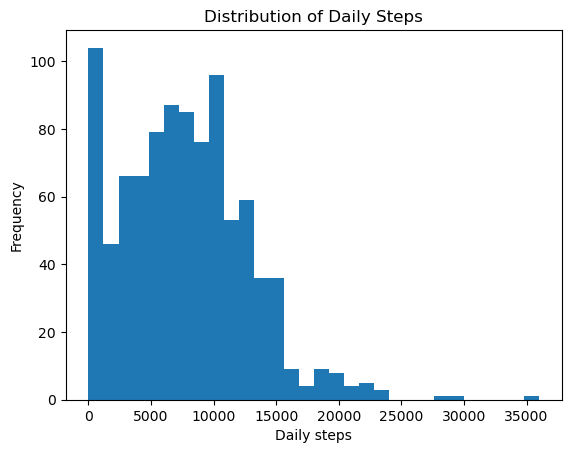

In [11]:
import matplotlib.pyplot as plt
pd_daily = spark.sql("SELECT total_steps FROM v_daily").toPandas().dropna()

plt.figure()
pd_daily["total_steps"].plot(kind="hist", bins=30)
plt.title("Distribution of Daily Steps")
plt.xlabel("Daily steps"); plt.ylabel("Frequency")
plt.show()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 15, Finished, Available, Finished)

<Figure size 640x480 with 0 Axes>

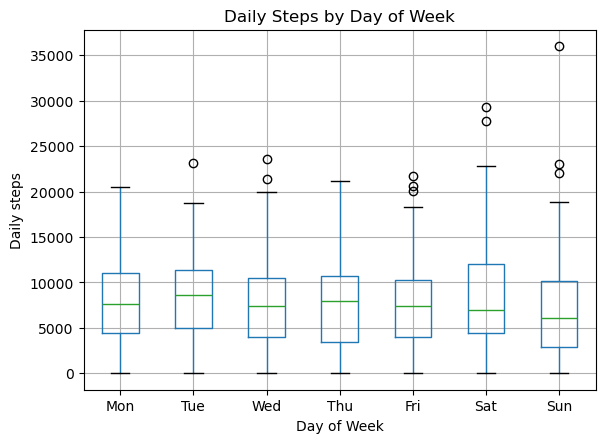

In [12]:
pd_dow = spark.sql("SELECT dow, total_steps FROM v_daily").toPandas().dropna()
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
pd_dow["dow"] = pd_dow["dow"].astype("category").cat.set_categories(order, ordered=True)

plt.figure()
pd_dow.boxplot(column="total_steps", by="dow")
plt.title("Daily Steps by Day of Week"); plt.suptitle("")
plt.xlabel("Day of Week"); plt.ylabel("Daily steps")
plt.show()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 16, Finished, Available, Finished)

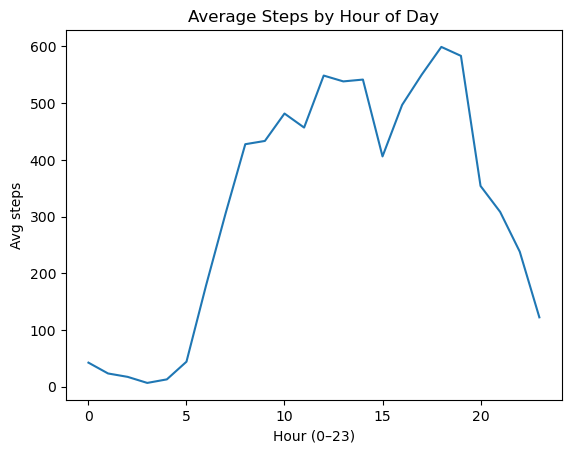

In [13]:
pd_hour = (spark.sql("""
  SELECT hour, AVG(COALESCE(Steps_HourlySum,0)) AS avg_steps_hour
  FROM v_final
  WHERE hour IS NOT NULL
  GROUP BY hour
  ORDER BY hour
""")).toPandas()

plt.figure()
plt.plot(pd_hour["hour"], pd_hour["avg_steps_hour"])
plt.title("Average Steps by Hour of Day")
plt.xlabel("Hour (0–23)"); plt.ylabel("Avg steps")
plt.show()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 17, Finished, Available, Finished)

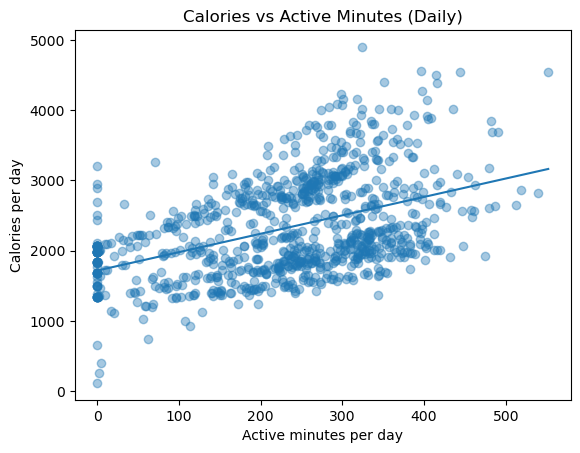

Approx slope (cal/min): 2.62


In [14]:
import numpy as np
pdf = spark.sql("SELECT active_minutes_day, calories_daily FROM v_daily").toPandas().dropna()
x, y = pdf["active_minutes_day"].values, pdf["calories_daily"].values
m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, alpha=0.4)
plt.plot(np.sort(x), m*np.sort(x)+b)
plt.title("Calories vs Active Minutes (Daily)")
plt.xlabel("Active minutes per day"); plt.ylabel("Calories per day")
plt.show()

print("Approx slope (cal/min):", round(m, 2))


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 18, Finished, Available, Finished)

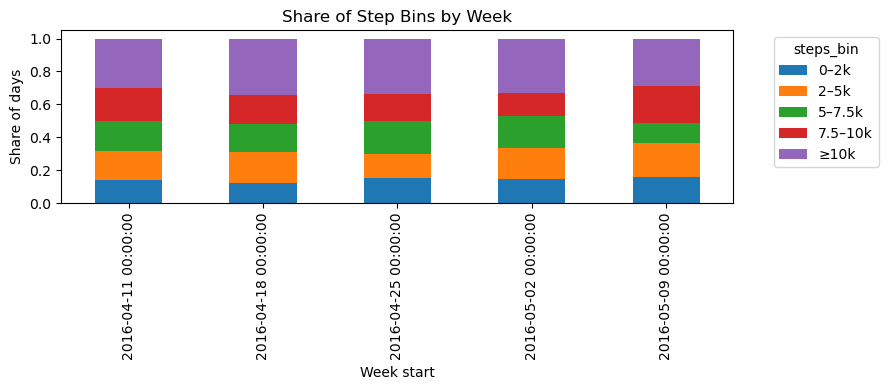

In [15]:
pd_bins = (spark.sql("""
  SELECT date_trunc('WEEK', date) AS week_start, steps_bin, COUNT(*) AS n
  FROM v_daily
  GROUP BY date_trunc('WEEK', date), steps_bin
""")).toPandas()

pivot = pd_bins.pivot_table(index="week_start", columns="steps_bin", values="n", aggfunc="sum").fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

pivot_pct.plot(kind="bar", stacked=True, figsize=(9,4))
plt.title("Share of Step Bins by Week")
plt.xlabel("Week start"); plt.ylabel("Share of days")
plt.legend(title="steps_bin", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.show()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 19, Finished, Available, Finished)

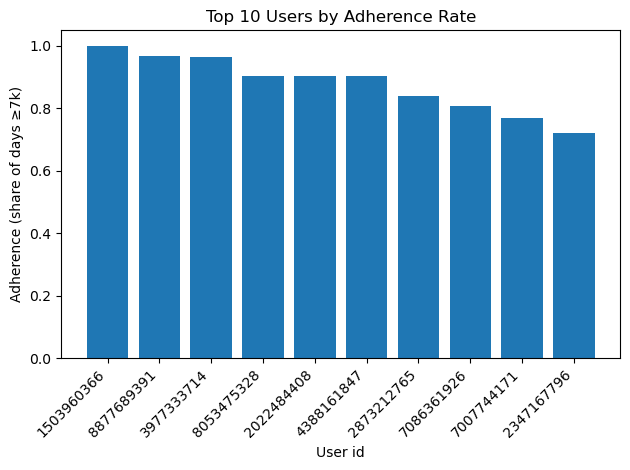

,id,adherence_rate,avg_steps
0,1503960366,1.000000,12520.633333
1,8877689391,0.967742,16040.032258
2,3977333714,0.965517,11337.620690
3,8053475328,0.903226,14763.290323
4,2022484408,0.903226,11370.645161
5,4388161847,0.903226,10813.935484
6,2873212765,0.838710,7555.774194
7,7086361926,0.806452,9371.774194
8,7007744171,0.769231,11323.423077
9,2347167796,0.722222,9519.666667


In [16]:
pd_top = (spark.sql("""
  SELECT id,
         AVG(CASE WHEN total_steps >= 7000 THEN 1 ELSE 0 END) AS adherence_rate,
         AVG(total_steps) AS avg_steps
  FROM v_daily
  GROUP BY id
  ORDER BY adherence_rate DESC, avg_steps DESC
  LIMIT 10
""")).toPandas()

plt.figure()
plt.bar(pd_top["id"].astype(str), pd_top["adherence_rate"])
plt.title("Top 10 Users by Adherence Rate")
plt.xlabel("User id"); plt.ylabel("Adherence (share of days ≥7k)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

pd_top  # optional table screenshot too


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 20, Finished, Available, Finished)

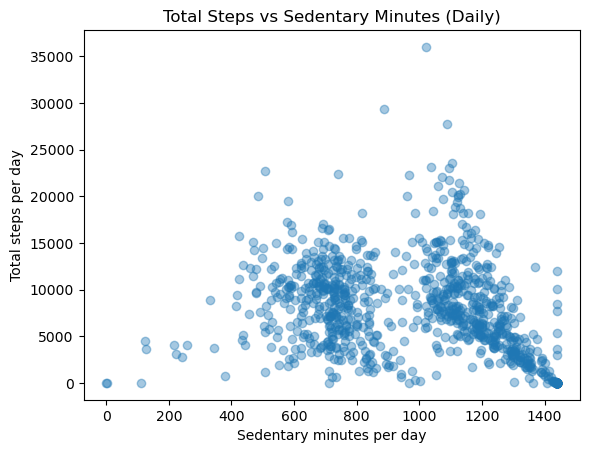

In [17]:
# Build a daily (id,date) dataset with total_steps and sedentary_minutes
pd_sed = spark.sql("""
  SELECT d.id, d.date,
         FIRST(d.total_steps)        AS total_steps,
         FIRST(f.SedentaryMinutes)   AS sedentary_minutes
  FROM v_daily d
  JOIN v_final f
    ON d.id = f.id AND d.date = f.date
  GROUP BY d.id, d.date
""").toPandas().dropna()

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(pd_sed["sedentary_minutes"], pd_sed["total_steps"], alpha=0.4)
plt.title("Total Steps vs Sedentary Minutes (Daily)")
plt.xlabel("Sedentary minutes per day")
plt.ylabel("Total steps per day")
plt.show()


StatementMeta(, e85749df-eef1-4697-a86c-925845913187, 21, Finished, Available, Finished)

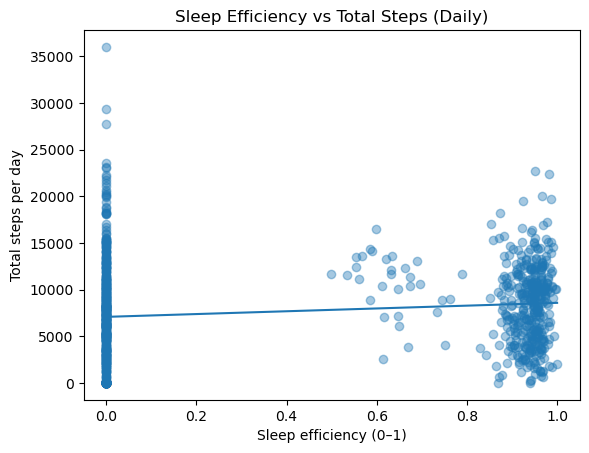

Approx slope (steps per +1.0 sleep efficiency): 1503.0
≈ steps per +0.1 sleep efficiency: 150.3


In [18]:
# Build a daily (id,date) dataset with total_steps and sleep_efficiency
pd_sleep = spark.sql("""
  SELECT d.id, d.date,
         FIRST(d.total_steps)      AS total_steps,
         FIRST(f.sleep_efficiency) AS sleep_efficiency
  FROM v_daily d
  JOIN v_final f
    ON d.id = f.id AND d.date = f.date
  WHERE f.sleep_efficiency IS NOT NULL
  GROUP BY d.id, d.date
""").toPandas().dropna()

# Keep efficiency in [0,1] just in case
pd_sleep = pd_sleep[(pd_sleep["sleep_efficiency"] >= 0) & (pd_sleep["sleep_efficiency"] <= 1)]

import matplotlib.pyplot as plt
import numpy as np

x = pd_sleep["sleep_efficiency"].values
y = pd_sleep["total_steps"].values

# Simple linear fit for a descriptive trend line
m, b = np.polyfit(x, y, 1)            # steps = m * sleep_efficiency + b
delta_per_point1 = m * 0.1            # steps change per +0.1 in sleep efficiency

plt.figure()
plt.scatter(x, y, alpha=0.4)
# sorted x for a clean line
xs = np.sort(x)
plt.plot(xs, m*xs + b)
plt.title("Sleep Efficiency vs Total Steps (Daily)")
plt.xlabel("Sleep efficiency (0–1)")
plt.ylabel("Total steps per day")
plt.show()

print("Approx slope (steps per +1.0 sleep efficiency):", round(m, 1))
print("≈ steps per +0.1 sleep efficiency:", round(delta_per_point1, 1))
